# Proyecto Machine Learning Datos Bancarios

## Importando las librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importando el dataset

In [ ]:
#Se importan desde una carpeta de Google Drive

train_transaction = pd.read_csv('/content/drive/MyDrive/fraud-detection-project/train_transaction.csv')
train_identity = pd.read_csv('/content/drive/MyDrive/fraud-detection-project/train_identity.csv')
# Optimizar tipos de dato para reducir uso de RAM
def reduce_memory(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                df[col] = df[col].astype('int32')
            else:
                df[col] = df[col].astype('float32')
    return df
train_transaction = reduce_memory(train_transaction)
train_identity = reduce_memory(train_identity)

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)


Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [ ]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## Juntar los dos datasets

Se usa left join (no inner) porque se necesita conservar todas las casi 600,000 transacciones, tengan o no información.
Si no se tiene match, solamente se pone como NaN.

In [ ]:
df = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity  # liberar memoria de las tablas originales, ya no las necesitas por separado

df.shape

(590540, 434)

## Revision de fraude
Para ver que tan desbalanceado está el target.Porcetaje de esfraudo sí o no.



In [ ]:
df['isFraud'].value_counts()
#df['isFraud'].value_counts(normalize=True) * 100

,count
isFraud,
0,569877
1,20663


##Panorama de nulls

Porcentaje de nulls por columna

In [ ]:
# % de nulos por columna, ordenado de mayor a menor
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

print(f"Columnas con al menos un nulo: {len(null_percentage)}")
null_percentage.head(30)

Columnas con al menos un nulo: 414


,0
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
id_26,99.125715
id_23,99.124699
id_22,99.124699
id_27,99.124699
dist2,93.628374


In [ ]:
# Agrupar columnas por rango de % de nulos
bins = [0, 10, 30, 50, 70, 90, 100]
labels = ['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%']

null_ranges = pd.cut(null_percentage, bins=bins, labels=labels, include_lowest=True)
null_ranges.value_counts().sort_index()

,count
0-10%,92
10-30%,90
30-50%,18
50-70%,6
70-90%,196
90-100%,12


In [ ]:
#Visualizamos las colmnas con mayor porcentja de nulls.
#Verificamos cuales son,nombre de las columnas, para después pensar como procesarlas.
cols_70_90 = null_percentage[(null_percentage > 70) & (null_percentage <= 90)].index.tolist()
print(len(cols_70_90))
print(cols_70_90[:30])  # primeras 30 para ver el patrón

196
['D13', 'D14', 'D12', 'id_04', 'id_03', 'D6', 'id_33', 'id_10', 'D8', 'id_09', 'D9', 'id_30', 'id_32', 'id_34', 'id_14', 'V146', 'V147', 'V148', 'V158', 'V157', 'V153', 'V162', 'V161', 'V139', 'V138', 'V141', 'V140', 'V163', 'V155', 'V156']


In [ ]:
# ¿Las transacciones sin info de identidad tienen más o menos fraude?

#Esto sirve para agrupar en 2 grupos, tiene identidad o no
#(basandonos en el paso pasado, donde 0 se pone a nan o null y 1 a lo que si tiene valor)

#una vez agrupado, se calcula el promedio de cada grupo por su correspondiente columna isFraud
df['has_identity'] = df['id_01'].notna().astype(int)
df.groupby('has_identity')['isFraud'].mean()

,isFraud
has_identity,
0,0.020939
1,0.078470


##Tipos de datos generales

In [ ]:
df.dtypes.value_counts()

,count
float32,399
object,31
int32,4
int64,1


In [ ]:
df['has_D13'] = df['D13'].notna().astype(int)
df.groupby('has_D13')['isFraud'].mean()

,isFraud
has_D13,
0,0.026156
1,0.110360


## Automatizar los 2 pasos anteriores

En vez de hacer el proceso anterior uno por uno, se hace en un for loop.


In [ ]:
# Para cada columna con nulos, calcular la diferencia en tasa de fraude entre "tiene dato" vs "no tiene dato"
resultados = []

for col in null_percentage.index:
    tiene_dato = df[col].notna().astype(int)
    tasa_con = df.loc[tiene_dato == 1, 'isFraud'].mean()
    tasa_sin = df.loc[tiene_dato == 0, 'isFraud'].mean()
    diferencia = abs(tasa_con - tasa_sin)
    resultados.append({'columna': col, 'tasa_con_dato': tasa_con, 'tasa_sin_dato': tasa_sin, 'diferencia': diferencia})

df_diferencias = pd.DataFrame(resultados).sort_values('diferencia', ascending=False)
df_diferencias.head(20)

,columna,tasa_con_dato,tasa_sin_dato,diferencia
413,V316,0.034987,0.166667,0.131679
412,V310,0.034987,0.166667,0.131679
411,V311,0.034987,0.166667,0.131679
410,V312,0.034987,0.166667,0.131679
409,V309,0.034987,0.166667,0.131679
408,V306,0.034987,0.166667,0.131679
407,V307,0.034987,0.166667,0.131679
390,V285,0.034987,0.166667,0.131679
389,V292,0.034987,0.166667,0.131679
388,V291,0.034987,0.166667,0.131679


In [ ]:
df['V316'].isna().sum()  # cuántas filas NO tienen dato en esta columna

np.int64(12)

## Segunda Prueba

Se vuelve a hacer el loop pero con porcentaje en cada columna.

In [ ]:
resultados = []

for col innp.int64(12)
$0 null_percentage.index:
    tiene_dato = df[col].notna().astype(int)
    n_con = (tiene_dato == 1).sum()
    n_sin = (tiene_dato == 0).sum()

    # Solo considerar si ambos grupos tienen al menos 1000 filas
    if n_con >= 1000 and n_sin >= 1000:
        tasa_con = df.loc[tiene_dato == 1, 'isFraud'].mean()
        tasa_sin = df.loc[tiene_dato == 0, 'isFraud'].mean()
        diferencia = abs(tasa_con - tasa_sin)
        resultados.append({
            'columna': col,
            'n_con_dato': n_con,
            'n_sin_dato': n_sin,
            'tasa_con_dato': tasa_con,
            'tasa_sin_dato': tasa_sin,
            'diferencia': diferencia
        })

df_diferencias_confiables = pd.DataFrame(resultados).sort_values('diferencia', ascending=False)
df_diferencias_confiables.head(20)

,columna,n_con_dato,n_sin_dato,tasa_con_dato,tasa_sin_dato,diferencia
10,D7,38917,551623,0.148778,0.026962,0.121816
321,addr2,524834,65706,0.024621,0.117813,0.093192
320,addr1,524834,65706,0.024621,0.117813,0.093192
14,D12,64717,525823,0.117403,0.024847,0.092557
13,D14,62187,528353,0.115989,0.025456,0.090532
12,D13,61952,528588,0.110360,0.026156,0.084203
16,id_03,66324,524216,0.107231,0.025850,0.081381
15,id_04,66324,524216,0.107231,0.025850,0.081381
17,D6,73187,517353,0.105456,0.025022,0.080434
19,id_10,74926,515614,0.104463,0.024895,0.079568


## Creación de variables has_x de forma sistemática

In [ ]:
columnas_clave = ['D7', 'addr1', 'D12', 'D14', 'D13', 'id_03', 'id_04', 'D6',
                   'id_10', 'id_09', 'D9', 'D8', 'dist2', 'id_13',
                   'R_emaildomain', 'id_05', 'id_06', 'id_02', 'DeviceType']

for col in columnas_clave:
    df[f'has_{col}'] = df[col].notna().astype(int)

df[[f'has_{col}' for col in columnas_clave]].head()

,has_D7,has_addr1,has_D12,has_D14,has_D13,has_id_03,has_id_04,has_D6,has_id_10,has_id_09,has_D9,has_D8,has_dist2,has_id_13,has_R_emaildomain,has_id_05,has_id_06,has_id_02,has_DeviceType
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


In [ ]:
columnas_clave = ['D7', 'addr1', 'D12', 'D14', 'D13', 'id_03', 'id_04', 'D6',
                   'id_10', 'id_09', 'D9', 'D8', 'dist2', 'id_13',
                   'id_05', 'id_06', 'id_02']  # solo numéricas

for col in columnas_clave:
    df[col] = df[col].fillna(-999)

In [ ]:
df['R_emaildomain'] = df['R_emaildomain'].fillna('missing')
df['DeviceType'] = df['DeviceType'].fillna('missing')

In [ ]:
# Separar columnas numéricas y categóricas restantes con nulos
cols_con_nulos_restantes = df.columns[df.isnull().any()].tolist()

numericas_restantes = df[cols_con_nulos_restantes].select_dtypes(include=['float64', 'int64']).columns.tolist()
categoricas_restantes = df[cols_con_nulos_restantes].select_dtypes(include=['object']).columns.tolist()

print(f"Numéricas restantes con nulos: {len(numericas_restantes)}")
print(f"Categóricas restantes con nulos: {len(categoricas_restantes)}")

Numéricas restantes con nulos: 0
Categóricas restantes con nulos: 28


In [ ]:
categoricas_restantes = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).isnull().any()].tolist()
print(len(categoricas_restantes))
print(categoricas_restantes)

28
['card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceInfo']


In [ ]:
for col in categoricas_restantes:
    df[col] = df[col].fillna('missing')

In [ ]:
nulos_actuales = df.isnull().sum()
nulos_actuales = nulos_actuales[nulos_actuales > 0].sort_values(ascending=False)
print(f"Columnas con nulos: {len(nulos_actuales)}")
nulos_actuales.head(30)

Columnas con nulos: 367


,0
id_24,585793
id_25,585408
id_07,585385
id_08,585385
id_21,585381
id_26,585377
id_22,585371
id_18,545427
id_32,512954
id_14,510496


In [ ]:
null_pct_actual = (df.isnull().sum() / len(df)) * 100
null_pct_actual = null_pct_actual[null_pct_actual > 0].sort_values(ascending=False)
print(f"Columnas con nulos restantes: {len(null_pct_actual)}")
null_pct_actual

Columnas con nulos restantes: 367


,0
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
...,...
V317,0.002032
V316,0.002032
V319,0.002032
V318,0.002032


In [ ]:
cols_a_eliminar = null_pct_actual[null_pct_actual > 90].index.tolist()
print(f"Columnas a eliminar: {len(cols_a_eliminar)}")
print(cols_a_eliminar)

df = df.drop(columns=cols_a_eliminar)

Columnas a eliminar: 8
['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_22', 'id_18']


In [ ]:
numericas_restantes = df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
numericas_restantes = [col for col in numericas_restantes if df[col].isnull().any()]

for col in numericas_restantes:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum().sum()

np.int64(0)

## EDA de negocio

Monto promedio, fraude vs no fraude

In [ ]:
df.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511658,239.398010,0.251,43.970001,68.5,120.0,31937.390625
1,20663.0,149.244781,232.210709,0.292,35.043999,75.0,161.0,5191.000000


##Fraude por dispositivo

In [ ]:
df.groupby('DeviceType')['isFraud'].mean().sort_values(ascending=False)

,isFraud
DeviceType,
mobile,0.101662
desktop,0.065215
missing,0.021017


## Evaluación del fraude por hora del día

In [ ]:
df['TransactionHour'] = (df['TransactionDT'] / 3600) % 24
df.groupby(df['TransactionHour'].astype(int))['isFraud'].mean()

/tmp/ipykernel_627/3200800244.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TransactionHour'] = (df['TransactionDT'] / 3600) % 24


,isFraud
TransactionHour,
0,0.031380
1,0.031314
2,0.037483
3,0.038314
4,0.051890
5,0.070302
6,0.077743
7,0.106102
8,0.093014


## Dominios de correo

In [ ]:

df.groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False).head(15)

,isFraud
P_emaildomain,
protonmail.com,0.407895
mail.com,0.189624
outlook.es,0.130137
aim.com,0.126984
outlook.com,0.094584
hotmail.es,0.065574
live.com.mx,0.054740
hotmail.com,0.052950
gmail.com,0.043542


Segun los resultados, protonmail puede ser un domino del cual provienen gran parte de los fraudes, 40%, pero también es posible que realmente haya muy pocos registros de este dominio a comparación de otros, por lo que se pondrá un umbral de registros de cada dominio.

In [ ]:
df['P_emaildomain'].value_counts().loc[['protonmail.com', 'mail.com', 'outlook.es', 'aim.com', 'outlook.com', 'hotmail.es', 'live.com.mx', 'hotmail.com', 'gmail.com']]

,count
P_emaildomain,
protonmail.com,76
mail.com,559
outlook.es,438
aim.com,315
outlook.com,5096
hotmail.es,305
live.com.mx,749
hotmail.com,45250
gmail.com,228355


Aquí se observa que efectivamente, son muy pocos registros, de los casi 600k, solo 76 tienen ese dominio, entonces si llega a tener unos 30 fraudes con ese dominio, abarcará mucho porcentaje, pero es un sesgo, porque el número de registros es muy bajo.

In [ ]:
email_counts = df['P_emaildomain'].value_counts()
dominios_confiables = email_counts[email_counts >= 1000].index

df[df['P_emaildomain'].isin(dominios_confiables)].groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False)

,isFraud
P_emaildomain,
outlook.com,0.094584
hotmail.com,0.052950
gmail.com,0.043542
icloud.com,0.031434
comcast.net,0.031187
missing,0.029538
bellsouth.net,0.027763
live.com,0.027622
anonymous.com,0.023217


Los dominios con mayor tasa de fraude son proveedores de correo gratuitos y de registro instantáneo (Outlook, Hotmail, Gmail) — es muy fácil crear una cuenta nueva sin verificación fuerte, lo cual los hace atractivos para defraudadores que necesitan generar identidades desechables rápidamente.

Los dominios con menor tasa de fraude son en su mayoría proveedores de internet/telecomunicaciones (AT&T, Verizon, SBCGlobal, Cox) — estos correos normalmente vienen ligados a un servicio contratado con verificación de identidad real (nombre, dirección, método de pago recurrente), lo que los hace mucho más difíciles de falsificar o usar de forma anónima.

##Fraude por tipo de producto (ProductCD)

In [ ]:
df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)

,isFraud
ProductCD,
C,0.116873
S,0.058996
H,0.047662
R,0.037826
W,0.020399


El tipo de producto muestra una variación considerable en tasa de fraude, desde 2.04% (producto W) hasta 11.69% (producto C) — una diferencia de casi 6 veces. Dado que la documentación oficial no revela el significado específico de cada categoría de producto (por confidencialidad del proveedor), este hallazgo se reporta como patrón observado, útil para ponderar el riesgo por categoría en un sistema de scoring, sin inferir causalidad específica sobre la naturaleza del producto.

## Fraude por tipo de tarjeta (crédito vs debito)

In [ ]:
df.groupby('card6')['isFraud'].mean().sort_values(ascending=False)

,isFraud
card6,
credit,0.066785
missing,0.024825
debit,0.024263
charge card,0.000000
debit or credit,0.000000


In [ ]:
df['card6'].value_counts()

,count
card6,
debit,439938
credit,148986
missing,1571
debit or credit,30
charge card,15


"Las tarjetas de crédito muestran una tasa de fraude (6.68%) casi 3 veces mayor que las de débito (2.43%), un patrón respaldado por muestras robustas (149K y 440K transacciones respectivamente). Las categorías 'charge card' y 'debit or credit' presentan 0% de fraude, pero al contar con muestras muy pequeñas (15 y 30 transacciones), este resultado no es estadísticamente representativo y se excluye de conclusiones generales

##Fraude por marca de tarjeta (visa, mastercard, etc.)

In [ ]:
df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)

,isFraud
card4,
discover,0.077282
visa,0.034756
mastercard,0.034331
american express,0.028698
missing,0.025999


In [ ]:
df['card4'].value_counts()

,count
card4,
visa,384767
mastercard,189217
american express,8328
discover,6651
missing,1577


Visa y Mastercard, las marcas dominantes (384K y 189K transacciones respectivamente), muestran tasas de fraude prácticamente idénticas (~3.4-3.5%), en línea con el promedio general. Discover, aunque con una base menor (6,651 transacciones), presenta una tasa notablemente mayor (7.73%) — más del doble del promedio — mientras que American Express muestra la tasa más baja entre las marcas principales (2.87%).

## ¿Hay un rango de monto más peligroso?

In [ ]:
df['AmtBucket'] = pd.cut(df['TransactionAmt'],
                           bins=[0, 25, 50, 100, 250, 500, 1000, df['TransactionAmt'].max()],
                           labels=['0-25', '25-50', '50-100', '100-250', '250-500', '500-1000', '1000+'])

df.groupby('AmtBucket')['isFraud'].agg(['mean', 'count'])

/tmp/ipykernel_627/1634626999.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AmtBucket'] = pd.cut(df['TransactionAmt'],
/tmp/ipykernel_627/1634626999.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AmtBucket')['isFraud'].agg(['mean', 'count'])


,mean,count
AmtBucket,,
0-25,0.061972,50829
25-50,0.030469,153695
50-100,0.029178,164095
100-250,0.030710,158907
250-500,0.053669,40135
500-1000,0.053100,15612
1000+,0.024632,7267


La tasa de fraude no varía de forma lineal con el monto de la transacción: se observan picos en transacciones pequeñas (0-25, 6.2%) — posiblemente transacciones de prueba con tarjetas comprometidas — y en el rango 250-1000 (5.3%), mientras que las transacciones de rango medio (50-250) y las de mayor monto (1000+) muestran las tasas más bajas.

In [ ]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,has_D8,has_dist2,has_id_13,has_R_emaildomain,has_id_05,has_id_06,has_id_02,has_DeviceType,TransactionHour,AmtBucket
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,0,0,0,0,0,0,0,0,0.000000,50-100
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0,0,0,0,0,0,0,0,0.000278,25-50
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0,0,0,0,0,0,0,0,0.019167,50-100
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,0,0,0,0,0,0,0,0,0.027500,25-50
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0,0,0,0,0,0,1,1,0.029444,25-50


# ============================================
# PASO 1: SPLIT
# ============================================


In [ ]:
from sklearn.model_selection import train_test_split

# Nota: TransactionID y AmtBucket se pueden dropear antes o después, no es leakage.
# Los dropeamos aquí para no arrastrarlos.
df = df.drop(columns=['TransactionID', 'AmtBucket'])
df['TransactionHour'] = df['TransactionHour'].astype('float32')

X = df.drop(columns=['isFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(472432, 445) (118108, 445)


In [ ]:
import gc

del df, X, y
gc.collect()

0

# ============================================
# PASO 2: ONE-HOT ENCODING — ronda 1 (aplicado por separado, luego alineado)
# ============================================
Lo que se hará es en variables de objetos, como texto, se transformara en un arreglo binario. Por ejemplo, en dispositivos, hay: teléfono, laptop, computadora, otros. En vez de dejarlo asi, categorizamos a teléfono como 1 0 0 0, laptop como 0 1 0 0, computadora como 0 0 1 0, otros como 0 0 0 1. Esto sirve para objetos con pocas categóricas. Para columnas con más categorías, se usará label encoding (más adelante)

In [ ]:
columnas_onehot = ['DeviceType', 'card4', 'card6', 'ProductCD',
                    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

# Ronda 2
columnas_onehot_2 = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28',
                     'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

todas_onehot = columnas_onehot + columnas_onehot_2

X_train = pd.get_dummies(X_train, columns=todas_onehot, prefix=todas_onehot)
X_test = pd.get_dummies(X_test, columns=todas_onehot, prefix=todas_onehot)

# Alinear columnas: si alguna categoría solo apareció en train o en test,
# esto asegura que ambos dataframes tengan exactamente las mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# ============================================
# PASO 3: LABEL ENCODING — ronda 1 y 2 (fit SOLO con train)
# ============================================

Se usa de forma similar que el one hot, solo que estos casos, el one hot generará muchs columnas de categoricas unicas.


In [ ]:
from sklearn.preprocessing import LabelEncoder

columnas_label = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']  # ronda 1
columnas_label_2 = ['id_30', 'id_31', 'id_33']  # ronda 2
todas_label = columnas_label + columnas_label_2

encoders = {}  # guardamos cada encoder por si lo necesitas después (ej. para producción)

for col in todas_label:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Manejo de categorías nuevas en test que el encoder nunca vio en train:
    # se les asigna un valor fuera de rango en vez de tronar
    test_vals = X_test[col].astype(str)
    known = set(le.classes_)
    test_vals = test_vals.apply(lambda x: x if x in known else 'unseen')

    # Si aparece 'unseen', hay que agregarlo temporalmente al encoder
    if 'unseen' in test_vals.values:
        le.classes_ = np.append(le.classes_, 'unseen')

    X_test[col] = le.transform(test_vals)
    encoders[col] = le

# ============================================
# Verificación final
# ============================================


In [ ]:
print(X_train.shape, X_test.shape)
print(X_train.select_dtypes(include=['object']).columns.tolist())  # debe salir []

(472432, 506) (118108, 506)
[]


In [ ]:
import gc
from sklearn.preprocessing import StandardScaler
import numpy as np

# Aseguramos que X_train/X_test ya estén en float32 antes de escalar
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

scaler = StandardScaler(copy=False)  # evita crear una copia extra innecesaria
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
gc.collect()  # fuerza liberar memoria de lo que ya no se usa

X_test_scaled = scaler.transform(X_test).astype(np.float32)
gc.collect()

print("Escalado completo:", X_train_scaled.shape, X_test_scaled.shape)

Escalado completo: (472432, 506) (118108, 506)


In [ ]:


print(f"Peso de X_train: {X_train.memory_usage(deep=True).sum() / 1e9:.2f} GB")
import psutil
print(f"RAM disponible antes de entrenar: {psutil.virtual_memory().available / 1e9:.2f} GB")


Peso de X_train: 0.96 GB
RAM disponible antes de entrenar: 5.58 GB


# ============================================
# Entrenar Bloque con class_weight
# ============================================


In [ ]:

# class_weight='balanced' le dice al modelo: "como solo el 3.5% de los datos
# son fraude, penaliza MÁS los errores en esa clase minoritaria durante el entrenamiento,
# como si cada ejemplo de fraude 'pesara' más que uno normal".
# Internamente, sklearn calcula ese peso como: n_samples / (n_clases * frecuencia_de_la_clase)
# Sin esto, el modelo aprendería que "predecir siempre 0" ya le da 96.5% de accuracy,
# y básicamente ignoraría el fraude por completo.

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    verbose=1
)

log_reg.fit(X_train_scaled, y_train)   # <-- aquí, no X_train

y_pred = log_reg.predict(X_test_scaled)              # <-- aquí, no X_test
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.4min finished


## Evaluar — con las métricas correctas (nunca Accuracy)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,  # esto es el Precision-Recall AUC
    recall_score
)

# --- Precision-Recall AUC ---
# Es LA métrica principal para clases desbalanceadas. Resume, en un solo número,
# qué tan bien el modelo distingue fraude de no-fraude a través de TODOS los umbrales posibles,
# sin dejarse engañar por la clase mayoritaria (que es lo que sí le pasa al accuracy o al ROC-AUC
# cuando el desbalance es tan fuerte como el tuyo).
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# --- Recall de la clase fraude ---
# De todos los fraudes reales que había en test, ¿qué porcentaje SÍ detectó el modelo?
# Esta es la métrica que más le importa al negocio: un fraude no detectado (falso negativo)
# le cuesta dinero real al banco.
recall_fraude = recall_score(y_test, y_pred)
print(f"Recall (fraude): {recall_fraude:.4f}")

# --- Matriz de confusión ---
# Te da el desglose exacto de los 4 escenarios posibles
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)
# Formato: [[Verdaderos Negativos, Falsos Positivos],
#           [Falsos Negativos,     Verdaderos Positivos]]

# --- Reporte completo (precision, recall, f1 por clase) ---
print(classification_report(y_test, y_pred, target_names=['No Fraude', 'Fraude']))

Precision-Recall AUC: 0.4447
Recall (fraude): 0.7416
Matriz de confusión:
[[95348 18627]
 [ 1068  3065]]
              precision    recall  f1-score   support

   No Fraude       0.99      0.84      0.91    113975
      Fraude       0.14      0.74      0.24      4133

    accuracy                           0.83    118108
   macro avg       0.57      0.79      0.57    118108
weighted avg       0.96      0.83      0.88    118108



## XGBoost


In [ ]:
#Importar xgboost

import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
#Se calcula scale_pos_weight, lo equivalente de clas_weight='balanced' en XGBoost
# scale_pos_weight = (# negativos) / (# positivos)
# Le dice al modelo cuánto más "importante" es cada ejemplo de fraude
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 27.58


##Entrenamiento

In [ ]:
# Los modelos basados en árboles (como XGBoost) no necesitan escalado de variables,
# porque no comparan magnitudes entre features como sí lo hace la Regresión Logística
# (que calcula distancias/productos punto). Por eso aquí usamos X_train, no X_train_scaled.

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',   # optimiza directamente para el área bajo la curva Precision-Recall
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
#Evaluación y comparación vs logistic regression
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

print(f"XGBoost — Precision-Recall AUC: {pr_auc_xgb:.4f}")
print(f"XGBoost — Recall (fraude): {recall_xgb:.4f}")
print("\nMatriz de confusión (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=['No Fraude', 'Fraude']))

print(f"\n--- Comparación ---")
print(f"Regresión Logística → PR-AUC: 0.4447 | Recall: 0.7416")
print(f"XGBoost              → PR-AUC: {pr_auc_xgb:.4f} | Recall: {recall_xgb:.4f}")

XGBoost — Precision-Recall AUC: 0.6743
XGBoost — Recall (fraude): 0.8207

Matriz de confusión (XGBoost):
[[104415   9560]
 [   741   3392]]
              precision    recall  f1-score   support

   No Fraude       0.99      0.92      0.95    113975
      Fraude       0.26      0.82      0.40      4133

    accuracy                           0.91    118108
   macro avg       0.63      0.87      0.68    118108
weighted avg       0.97      0.91      0.93    118108


--- Comparación ---
Regresión Logística → PR-AUC: 0.4447 | Recall: 0.7416
XGBoost              → PR-AUC: 0.6743 | Recall: 0.8207


##SHAP

In [ ]:
!pip install shap -q
import shap

In [ ]:
#Calcular vecores SHAP
#soLO muestra para optimizar tiempo

sample_size = 2000
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

print("Shape de shap_values:", shap_values.shape)

Shape de shap_values: (2000, 506)


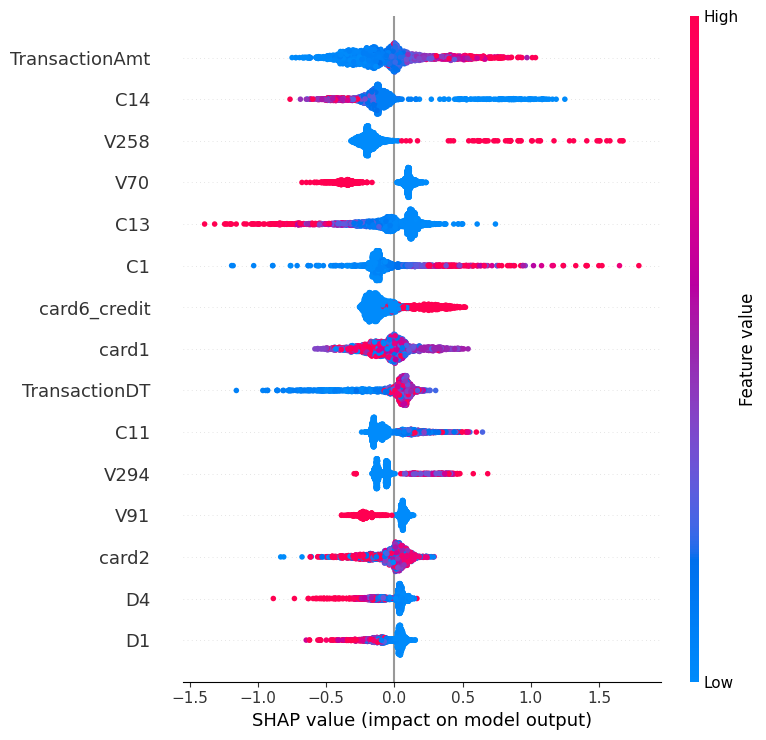

In [ ]:
#Revisar que variables importan más en general
shap.summary_plot(shap_values, X_test_sample, max_display=15)

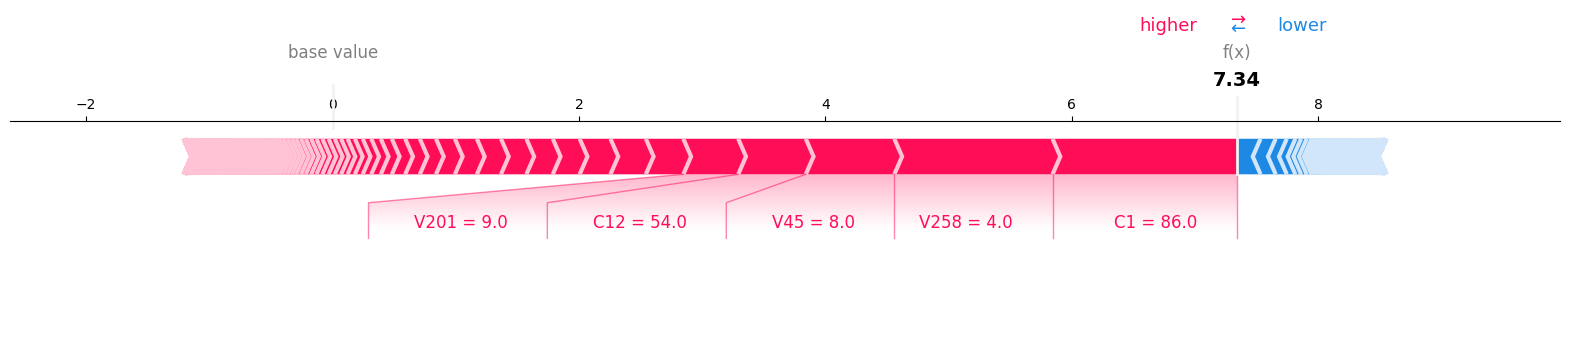

In [ ]:
#Explicacon de predicción especpifica
# Elegimos una transacción que el modelo marcó como fraude con alta probabilidad
idx_fraude = np.argmax(xgb_model.predict_proba(X_test_sample)[:, 1])

shap.force_plot(
    explainer.expected_value,
    shap_values[idx_fraude],
    X_test_sample.iloc[idx_fraude],
    matplotlib=True
)

In [ ]:
#Guardando modelo
xgb_model.save_model('modelo_fraude.json')
from google.colab import files
files.download('modelo_fraude.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Demos para fastapi


In [ ]:
features_demo = ['TransactionAmt', 'C14', 'C13', 'C1', 'card6_credit']

X_train_demo = X_train[features_demo]
X_test_demo = X_test[features_demo]

xgb_demo = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_demo.fit(X_train_demo, y_train)

proba_demo = xgb_demo.predict_proba(X_test_demo)[:, 1]
print("PR-AUC modelo demo (5 variables):", average_precision_score(y_test, proba_demo))

xgb_demo.save_model('modelo_fraude_demo.json')
from google.colab import files
files.download('modelo_fraude_demo.json')

PR-AUC modelo demo (5 variables): 0.45403282159743347


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>